In [80]:
import odl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import spsolve, lsqr
from scipy.sparse import lil_matrix, diags
from scipy.special import gamma
from mpl_toolkits.mplot3d import Axes3D

In [81]:
#  ------Building the space"""
R = 1.0
h = 0.05
r = 0.2
# given: R, r, h
start = -R - r

xx = np.arange(start, R + r, h)
yy = np.arange(start, R + r, h)

Nx, Ny = len(xx), len(yy)

# ODL space with the same sampling step h
space = odl.uniform_discr(
    min_pt=[xx[0], yy[0]],
    max_pt=[xx[-1] + h, yy[-1] + h],   # important: +h to match arange-excluded endpoint
    shape=[Nx, Ny],
    dtype='float64'
)

x = space.grid.coord_vectors[0]
y = space.grid.coord_vectors[1]

X, Y = np.meshgrid(x, y, indexing='ij')

In [82]:
# Calculate coordinates neighbouring within the mean value radius
I_max = int(np.ceil(r/h))
Q = (r/h)**2
cord = []
for i in range(-I_max, I_max+1):
    for j in range(-I_max, I_max+1):
        if i**2 + j**2 < Q:  # L2 radius
        #if np.abs(i) + np.abs(j) < Q:  # L1 radius
            cord.append((i, j))
cord = np.array(cord)

# --- Square domain ---
Z = np.zeros_like(X, dtype=bool)
Z[(np.abs(Y) <= 1.0) & (np.abs(X) <= 1.0)] = True

In [83]:
v =Z*(1 - np.max(np.array([np.abs(X), np.abs(Y)]), axis=0))
u = np.zeros_like(v)

p=3
tau = 0.2
max_iter = 5
tol = 10**(-6)

In [84]:
#   ---Test Cell

v = space.element(v)
u = space.element(u)
# --- convert ODL elements to numpy arrays (shape: (Nx, Ny)) ---
V = v.asarray()
U = u.asarray()

print("U shape:", U.shape, " ||U||:", np.linalg.norm(U))
print("V shape:", V.shape, " ||V||:", np.linalg.norm(V))

U shape: (48, 48)  ||U||: 0.0
V shape: (48, 48)  ||V||: 16.3401346384


In [85]:
def phi(u, p):
    '''
    computes the duality mapping from L^p to L^q

    Parameters
    ----------
    u       -   function that needs to be mapped
    p       -   p value

    Returns
    -------
    value   -   the duality map: |u|^{p-2}u

    '''
    if p==2:
        value = u
    else:
        value =  np.abs(u) ** (p - 1) * np.sign(u)
    return value


def dphi(r, p):
    '''
    derivative of the duality mapping from L^p to L^q
    we are taking care of the non-differentiable case p<2 by adding a small epsilon value

    Parameters
    ----------
    r       -   function that needs to be mapped
    p       -   p value

    Returns
    value   -   the derivative of duality map: (p-1)|r|^{p-2}
    -------

    '''
    epsilon = 1e-12
    if p<2:
        value = (p - 1) * (np.abs(r) + epsilon) ** (p - 2) #- np.sign(r) * (p-1) * epsilon**(p-2)
    elif p==2:
        value =  np.ones_like(r)
    else:
        value = (p - 1) * np.abs(r) ** (p - 2)
    return value


def disc_p_lap(p, r, h, Z, U, Dnp, cord):
    '''
    calculates the negative discrete p-Laplacian by approximating the p-Laplacian with the del Teso and Lindgren
    mean value approximation

    Parameters
    ----------
    p           -   p value
    r           -   radius of the mean value approximation
    h           -   spatial discretization
    Z           -   binary matrix, which defines the domain
    U           -   discretized function on which the p-Laplacian is applied to
    Dnp         -   scaling parameter for the mean value approximation
    cord        -   neighbouring coordinates within the mean value radius

    Returns
    -------
    negative p-Laplacian of U
    '''
    PL = np.zeros_like(Z, dtype=float)
    for i in range(Z.shape[1]):
        for j in range(Z.shape[0]):
            if Z[j, i] == 1:
                for k in range(cord.shape[0]):
                    x_offset = int(cord[k, 0])
                    y_offset = int(cord[k, 1])
                    U_neighbor = U[j + y_offset, i + x_offset]
                    U_current = U[j, i]
                    PL[j, i] += phi(U_neighbor - U_current, p)
    PL *= h**2 / (np.pi * r**2 * Dnp * r**p)
    # PL = PL #* (Z==1)
    return -PL

def jac_disc_p_lap(p, r, h, Z, U, Dnp, cord):
    '''
    calculates the Jacobian of the discrete approximation of the p-Laplacian of U -- not of negative p-Laplacian!

    Parameters
    ----------
    p       -   p value
    r       -   radius of the mean value approximation
    h       -   spatial discretization
    Z       -   binary matrix, which defines the domain
    U       -   discretized function on which the Jacobian of the discrete p-Laplacian is evaluated
    Dnp     -   scaling parameter for the mean value approximation
    cord    -    neighbouring coordinates within the mean value radius

    Returns
    -------
    a sparse Matrix which represents the Jacobian of the discrete p-Laplacian of U
    '''
    # calculates the jacobian of p-laplacian -- not of negative p-laplacian
    N, M = Z.shape
    J_matrix = lil_matrix((N * M, N * M))  # lil_matrix um die Matrix in COO-Format aufzubauen

    scale_factor = h**2 / (np.pi * r**2 * Dnp * r**p)

    for i in range(M):
        for j in range(N):
            idx = i * N + j  # 1D Index
            if Z[j, i] == 1:
                diag_contrib = 0  # Summe der Diagonalelemente für den Punkt (j, i)
                for k in range(cord.shape[0]):
                    x_offset = int(cord[k, 0])
                    y_offset = int(cord[k, 1])
                    neighbor_x = i + x_offset
                    neighbor_y = j + y_offset

                    neighbor_idx = neighbor_x * N + neighbor_y  # 1D Index des Nachbarn
                    r_val = U[neighbor_y, neighbor_x] - U[j, i]
                    J_value = dphi(r_val, p) * scale_factor
                    J_matrix[idx, neighbor_idx] = J_value
                    diag_contrib -= J_value

                J_matrix[idx, idx] = diag_contrib # Diagonaleintrag beachten
            else:
                J_matrix[idx, idx] = 1/scale_factor

    return J_matrix.tocsr()

def calc_dnp(p):
    '''
    Calculates the scaling parameter of the del Teso and Lindgren mean value approximation

    Parameters
    ----------
    p       -   p value

    Returns
    -------
    Dnp     -   scaling parameter of the mean value approximation
    '''
    if p % 2 == 0:
        P1 = np.arange(p-1, 0, -2)
        P2 = np.arange(p, 1, -2)
        Dnp = 1/(2 + p) * np.prod(P1) / np.prod(P2)
    elif p % 1 == 0:
        P1 = np.arange(p-1, 1, -2)
        P2 = np.arange(p, 2, -2)
        Dnp = 2/((2 + p) * np.pi) * np.prod(P1) / np.prod(P2)
    else:
        d=2
        Dnp = 1/np.sqrt(np.pi) * (p-1)/(d+p) * gamma((p-1)/2)/gamma((d+p)/2)
    return Dnp


In [86]:
# Functional data term
class CombinedFunctional(odl.solvers.Functional):
    def __init__(self, space, v, p, tau, r, h, Z, Dnp, cord):
        self.v = v
        self.p = float(p)
        self.tau = float(tau)
        self.r = float(r)
        self.h = float(h)
        self.Z = np.asarray(Z, dtype=bool)
        self.cord = np.asarray(cord, dtype=int)
        self.Dnp = float(Dnp)
        super().__init__(space=space, linear=False)


    def _call(self, u):
        U = u.asarray()
        V = self.v.asarray()

        data_part = (1.0 / self.p) * float(np.sum(np.abs(U - V) ** self.p))

        norm_grad = np.linalg.norm(np.array(np.gradient(U, edge_order=2)), axis=0)
        reg_part = self.tau * (1.0 / self.p) * np.linalg.norm(norm_grad.flatten(), ord=self.p) ** self.p

        return data_part + reg_part


    @property
    def gradient(self):
        v = self.v
        p = self.p
        tau = self.tau
        r = self.r
        h = self.h
        Z = self.Z
        Dnp = self.Dnp
        cord = self.cord
        space = self.domain

        class GradCombined(odl.Operator):
            def __init__(self):
                super().__init__(domain=space, range=space, linear=False)

            def _call(self, u, out=None):
                U = u.asarray()
                V = v.asarray()

                diff = U - V
                data_grad = phi(diff, p)
                #print("data Grad ",np.linalg.norm(data_grad))
                reg_grad = tau * disc_p_lap(p, r, h, Z, U, Dnp, cord)
                #print("Reg grad ",np.linalg.norm(reg_grad))

                val = space.element(data_grad + reg_grad)

                if out is None:
                    return val
                out.assign(val)
                return out

            def derivative(self, u):
                U = u.asarray()
                V = v.asarray()
                N, M = U.shape

                diff = U - V
                
                data_diag = dphi(diff, p).ravel()
                J_data = np.diag(data_diag)
                #print("J_data ",np.linalg.norm(data_diag))
                J_reg = tau * np.asarray(jac_disc_p_lap(p, r, h, Z, U, Dnp, cord))
                #print("J_reg ",np.linalg.norm(J_reg.toarray()))
                J_total = J_data + J_reg
                #print("J_total:", J_total.shape, " ||J_total||:", np.linalg.norm(J_total)) 
                
                class HessianAtU(odl.Operator):
                        def __init__(self):
                            super().__init__(domain=space, range=space, linear=True)

                        def _call(self, direction, out=None):
                            x_arr = direction.asarray().ravel()
                            y_arr = J_total @ x_arr
                            y_arr = np.asarray(y_arr).reshape((N, M))
                            val = space.element(y_arr)
                            if out is None:
                                return val
                            out.assign(val)
                            
                            return out

                return HessianAtU()

        return GradCombined()

In [87]:
Dnp = calc_dnp(p)   # Constant of the discretization
print("Value of Dnp", Dnp)
Functional = CombinedFunctional(space, v, p, tau, r, h, Z, Dnp, cord)

Value of Dnp 0.0848826363157


In [88]:
Functional(u)

53.444249999999876

In [89]:
Gradient = Functional.gradient(u)

In [90]:
print(np.linalg.norm(Gradient))
Gradient.shape

10.344038138


(48, 48)

In [91]:
derivative = Functional.gradient.derivative(u)


In [92]:
print("u shape:", u.shape, " ||u||:", np.linalg.norm(u))

u shape: (48, 48)  ||u||: 0.0


In [93]:
values = []
x_norms = []

def cb(x):
    values.append(float(Functional(x)))
    x_norms.append(x.norm())
    print("F(x):", float(Functional(x)), " ||x||:", x.norm())

U = u.copy()

odl.solvers.smooth.newton.newtons_method(
    f=Functional,
    x=U,
    line_search=1.0,
    maxiter=30,
    tol=1e-6,
    cg_iter=5,
    callback=cb
)

final_val = float(Functional(U))
print("Final value F(x):", final_val)
print("First plotted value:", values[0])
print("Last plotted value:", values[-1])

F(x): 6.690134619543819  ||x||: 0.4077795977725383
F(x): 6.66315960565592  ||x||: 0.41008903334112723
F(x): 6.551465992392244  ||x||: 0.43586805863822864
F(x): 7.240316855247881  ||x||: 0.4927733600087264
F(x): 10.822146519661752  ||x||: 0.5955861061428865
F(x): 23.853028681876708  ||x||: 0.7686981793492743
F(x): 69.89319129232241  ||x||: 1.051882862874926
F(x): 234.64666084091706  ||x||: 1.5016778079841286
F(x): 824.1741680722688  ||x||: 2.2004662695208186
F(x): 2919.060595168721  ||x||: 3.2722036490106894
F(x): 10307.710292681273  ||x||: 4.90472277054828
F(x): 36214.66582829798  ||x||: 7.382929724794997
F(x): 126670.80537767024  ||x||: 11.138263900765669
F(x): 441655.17187242344  ||x||: 16.82467161247285
F(x): 1536578.0810462649  ||x||: 25.431944592367415
F(x): 5338573.483814978  ||x||: 38.45850692766929
F(x): 18532662.633613713  ||x||: 58.173288168598496
F(x): 64306772.126244806  ||x||: 88.01141366594621
F(x): 223095520.22659418  ||x||: 133.17430500120096
F(x): 773952380.7769618  ||

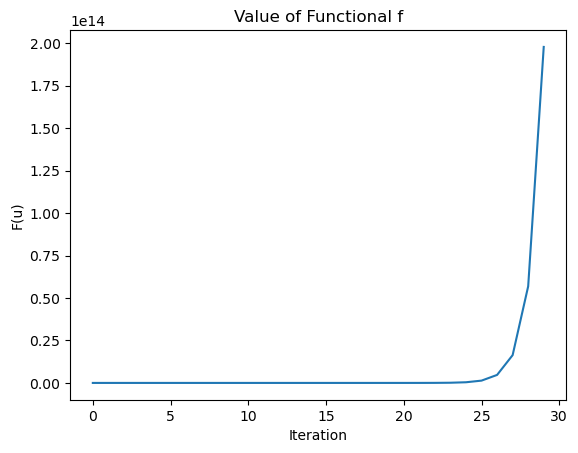

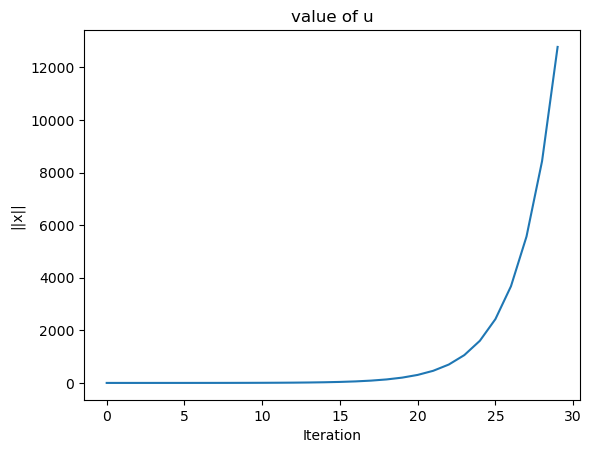

In [94]:
plt.plot(values)
plt.xlabel("Iteration")
plt.ylabel("F(u)")
plt.title("Value of Functional f")
plt.show()

plt.plot(x_norms)
plt.xlabel("Iteration")
plt.ylabel("||x||")
plt.title("value of u")
plt.show()

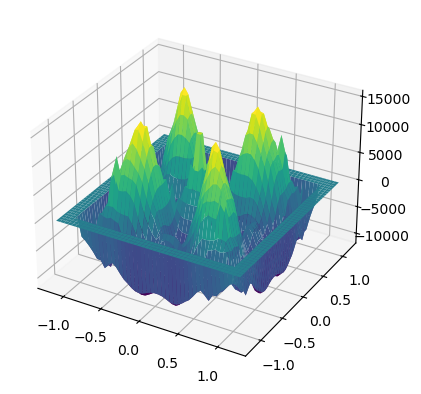

In [95]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,U, cmap='viridis')
plt.show()

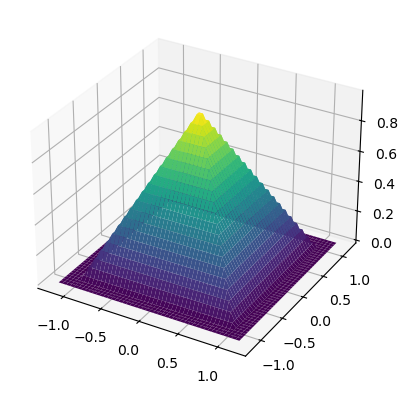

In [96]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,V, cmap='viridis')
plt.show()